# 06b — Extended Feature Analysis

Picks up from `06_features.ipynb` and performs:

1. **Velocity-regime splitting** — full dataset (A) vs speed-controlled subset (B)
2. **Log transform** — stabilises heavy-tailed energy / band-power features
3. **Full EDA** — distributions, heatmap, PCA, t-SNE on both datasets
4. **Mutual information** — ranks features by their predictive value for terrain label
5. **Correlation pruning** — drops near-duplicate features (|r| > 0.95)
6. **Save** — ready-to-model CSVs for `07_modelling.ipynb`

## The two datasets:

**Dataset A** retains all windows (full speed and condition diversity).  
This is what a real deployment sees — the classifier must be robust across speeds.

**Dataset B** keeps only windows where the robot moves at low, near-constant speed.  
At varying speeds, vibration intensity scales with velocity, which can mask terrain signal.  
Dataset B isolates the *terrain-driven* vibration, making class differences clearer and  
feature importance more interpretable during development.

---
**Depends on:** `06_features.ipynb`  
**Feeds into:** `07_modelling.ipynb`

## Cell 1 — Imports and load features

In [ ]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

# ── Project root ──────────────────────────────────────────────────────────
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / "src").exists() else cwd.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features import (
    get_feature_columns,
    get_eda_feature_columns,
    split_velocity_regime_datasets,
    apply_log_transform,
    compute_mutual_information,
    drop_high_correlation_features,
    run_feature_evaluation,
    print_feature_diagnostics,
)

# ── Config ────────────────────────────────────────────────────────────────
RANDOM_STATE    = 42
TOP_N_HEATMAP   = 25
TSNE_SAMPLE_CAP = 2500
VEL_COL         = "odom_mean_speed"   # produced by compute_window_features

ID_COLS = ["window_id", "run_id", "segment_id", "label", "t_start", "t_end", "n_samples"]

# ── Load ──────────────────────────────────────────────────────────────────
features_path = PROJECT_ROOT / "data" / "processed" / "window_features.csv"
if not features_path.exists():
    raise FileNotFoundError(
        f"{features_path}\nRun 06_features.ipynb first."
    )

features_df  = pd.read_csv(features_path, low_memory=False)
feature_cols = get_feature_columns(features_df, id_cols=ID_COLS)

print(f"Loaded features_df : {features_df.shape}")
print(f"Feature columns    : {len(feature_cols)}")
print(f"Velocity col present: {VEL_COL in features_df.columns}")
print(f"\nLabel distribution:")
print(features_df["label"].value_counts().sort_index().to_string())

Loaded features_df: (1729, 238)
Feature columns   : 231
Velocity column present: True


## Cell 2 — Velocity-regime split

**Dataset A:** every window  
**Dataset B:** only windows where `odom_mean_speed < 0.6 m/s` AND `odom_speed_std < 0.10 m/s`


In [ ]:
MEAN_SPEED_THRESH = 0.6    # m/s — max mean speed for Dataset B
SPEED_STD_THRESH  = 0.10   # m/s — max speed std (enforces near-constant speed)

dataset_A, dataset_B = split_velocity_regime_datasets(
    features_df,
    vel_col     = VEL_COL,
    mean_thresh = MEAN_SPEED_THRESH,
    std_thresh  = SPEED_STD_THRESH,
    label_col   = "label",
    verbose     = True,
)

print(f"\nDataset A shape : {dataset_A.shape}")
print(f"Dataset B shape : {dataset_B.shape}")

DATASET A — Full Dataset
Total windows: 1729
Class distribution:
  dry_dirt_track                   652  (37.7%)
  grass                            386  (22.3%)
  muddy_dirt_track                 145  (8.4%)
  smooth_terrain                   546  (31.6%)

DATASET B — Low Constant-Velocity Subset
  Criteria: odom_mean_velocity < 0.6 m/s  AND  odom_vel_std < 0.1 m/s
Windows kept:     1160  (67.1%)
Windows removed:   569  (32.9%)
Class distribution:
  dry_dirt_track                   523  (45.1%)
  grass                            354  (30.5%)
  muddy_dirt_track                  75  (6.5%)
  smooth_terrain                   208  (17.9%)

  ⚠ WARNING: 'muddy_dirt_track' has only 75 windows in Dataset B.

Dataset A shape: (1729, 238)
Dataset B shape: (1160, 238)


## Cell 3 — Log1p transform on heavy-tailed features

Band-power and energy features are right-skewed (most windows have low power, 
a few have very high power).  `log1p` compresses the tail so classifiers that 
assume near-Gaussian distributions (e.g. LDA, SVM with RBF) work better.

This is applied **before** EDA so plots and MI scores reflect the transformed  
values that will actually be fed to the model.

In [ ]:
dataset_A_tf = apply_log_transform(dataset_A)
dataset_B_tf = apply_log_transform(dataset_B)

print(f"\nDataset A (transformed) shape : {dataset_A_tf.shape}")
print(f"Dataset B (transformed) shape : {dataset_B_tf.shape}")

Applied log1p transform to 8 columns: ['acc_mag_bandpower_5_20Hz', 'acc_mag_bandpower_20_40Hz', 'acc_mag_bandpower_40_80Hz', 'gyro_mag_bandpower_5_20Hz', 'gyro_mag_bandpower_20_40Hz', 'gyro_mag_bandpower_40_80Hz', 'gyro_mag_energy', 'acc_mag_energy']
Applied log1p transform to 8 columns: ['acc_mag_bandpower_5_20Hz', 'acc_mag_bandpower_20_40Hz', 'acc_mag_bandpower_40_80Hz', 'gyro_mag_bandpower_5_20Hz', 'gyro_mag_bandpower_20_40Hz', 'gyro_mag_bandpower_40_80Hz', 'gyro_mag_energy', 'acc_mag_energy']


## Cell 4 — Full EDA: Dataset A (all windows)

Using the EDA feature subset (drops very noisy / low-information features like
min, max, range, spectral centroid) to keep plots and the heatmap readable.

Feature table diagnostics
Shape: (1729, 238)
Feature count: 231
Total missing values in feature columns: 0

Label distribution:
                  count    pct
label                         
dry_dirt_track      652  37.71
grass               386  22.33
muddy_dirt_track    145   8.39
smooth_terrain      546  31.58

Quick summary (key separator candidates):
                  acc_mag_rms  acc_mag_std  acc_mag_energy  gyro_mag_rms  gyro_mag_std  gyro_mag_energy
label                                                                                                  
dry_dirt_track         0.1544       0.0685          1.6014       11.9358        1.9738          10.2430
grass                  0.1451       0.0623          1.5124       12.2009        2.4188          10.2795
muddy_dirt_track       0.1589       0.0741          1.6322       11.3092        2.1882          10.1273
smooth_terrain         0.1616       0.0741          1.6879       10.7476        1.2551          10.0363


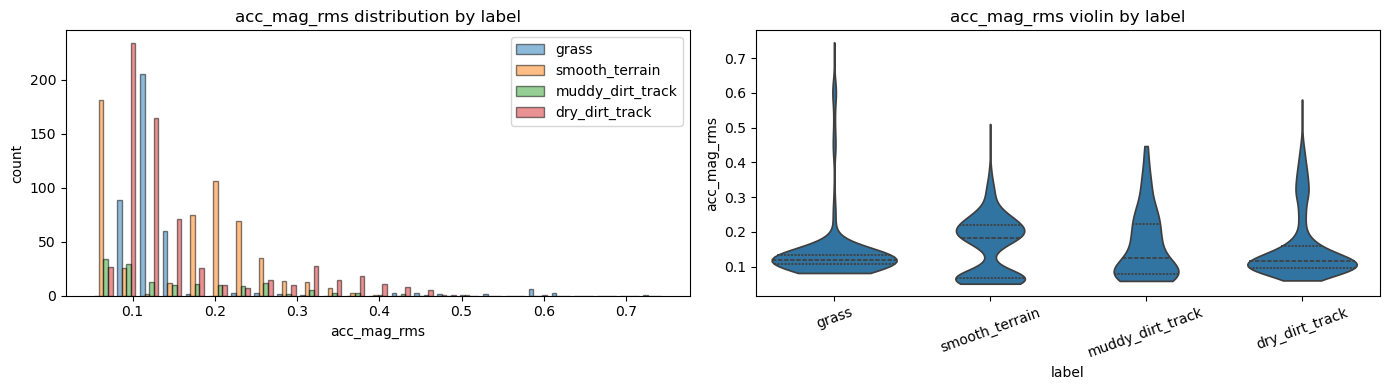

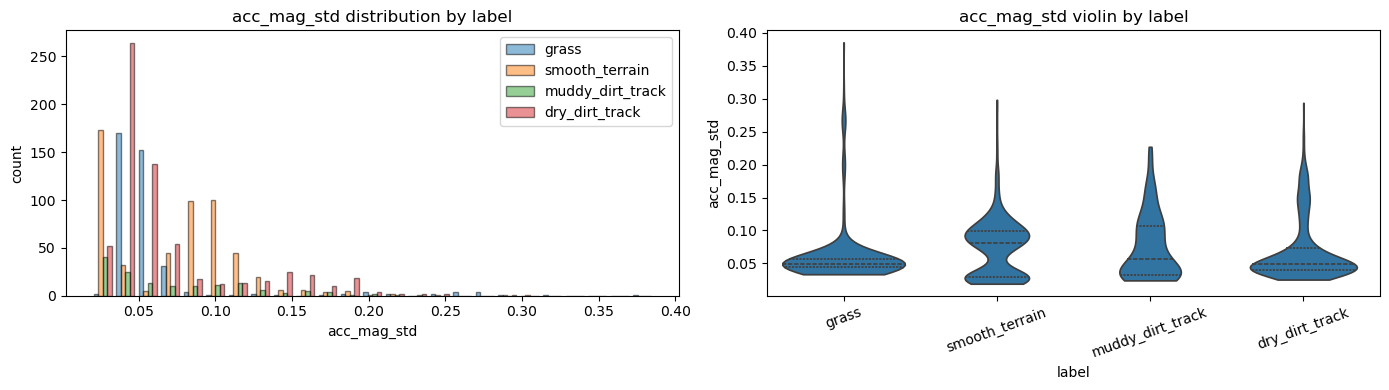

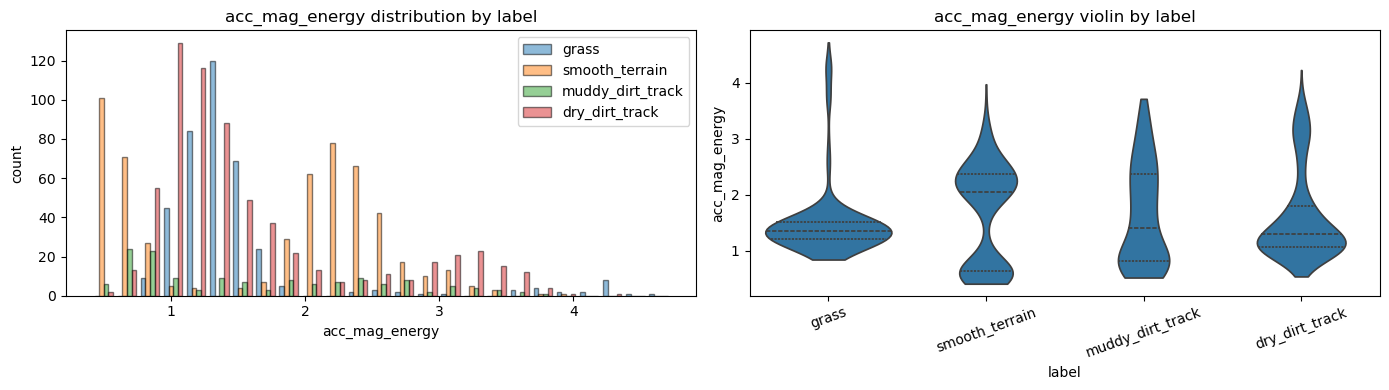

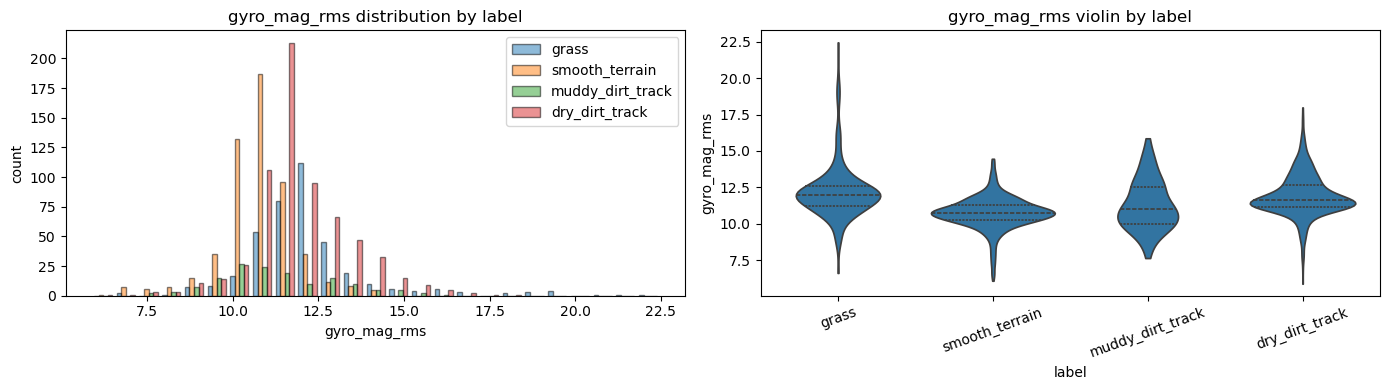

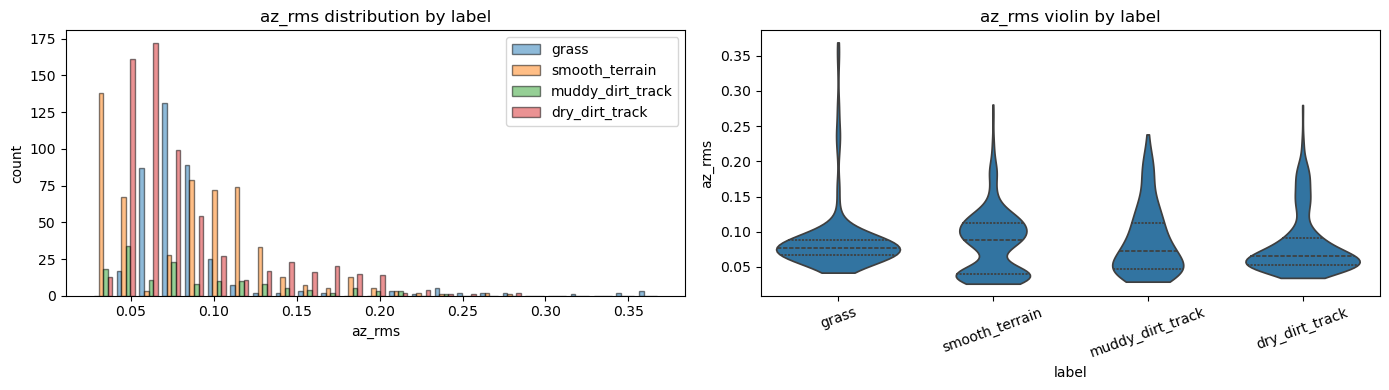

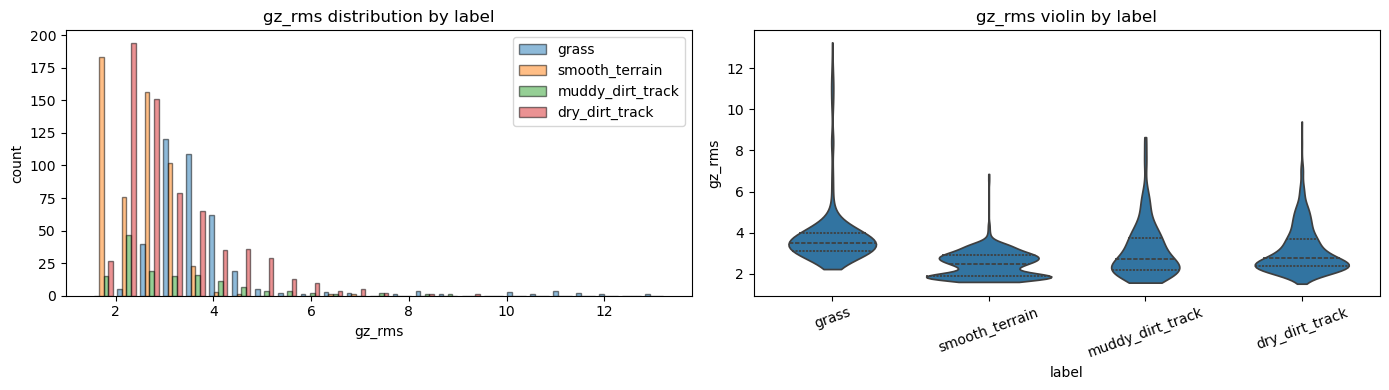

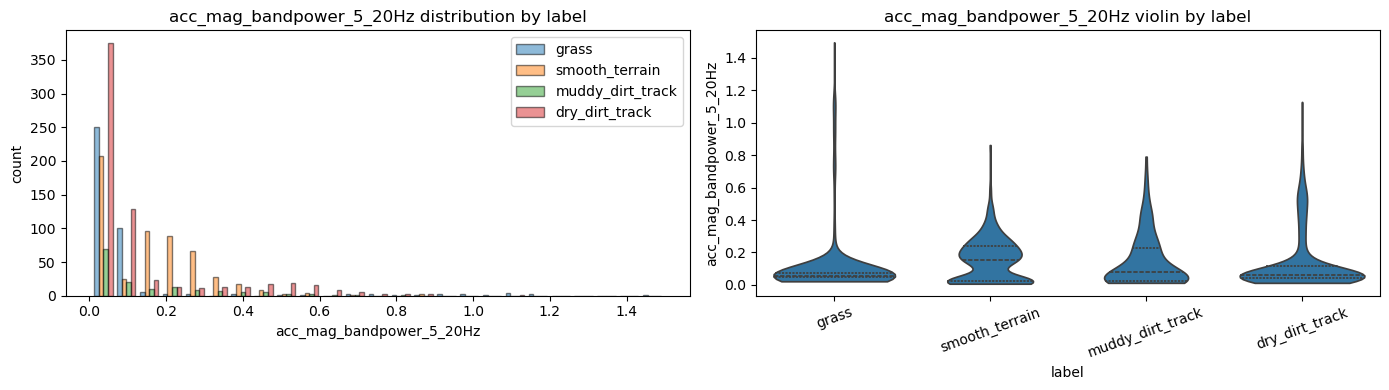

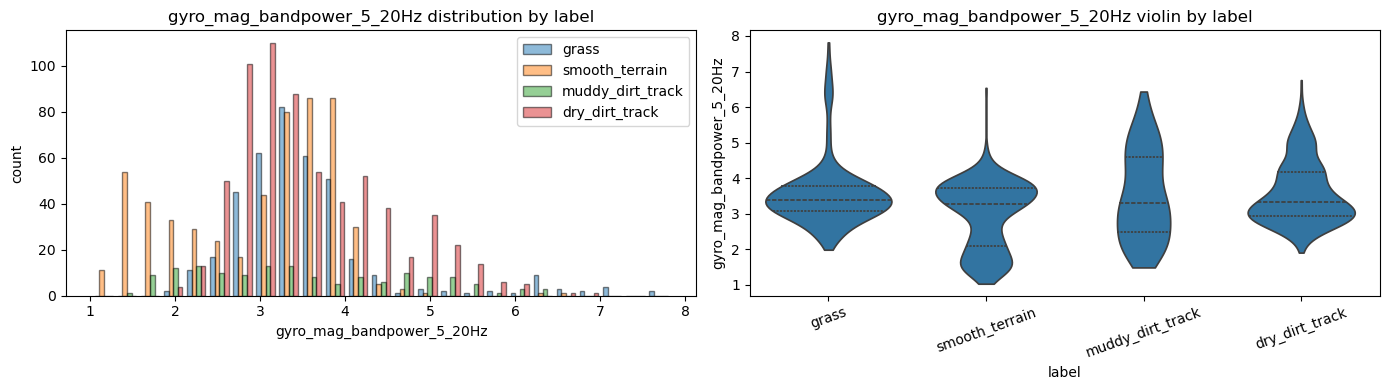

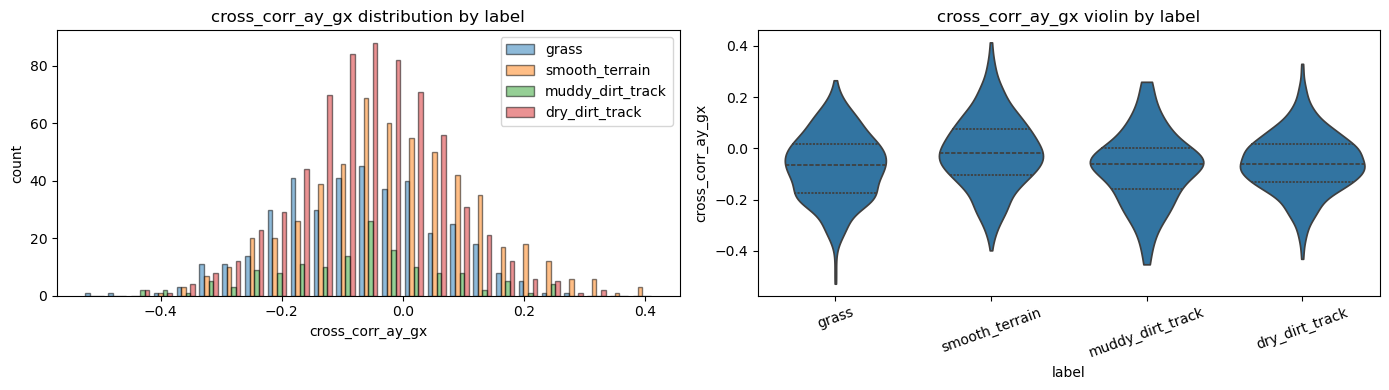

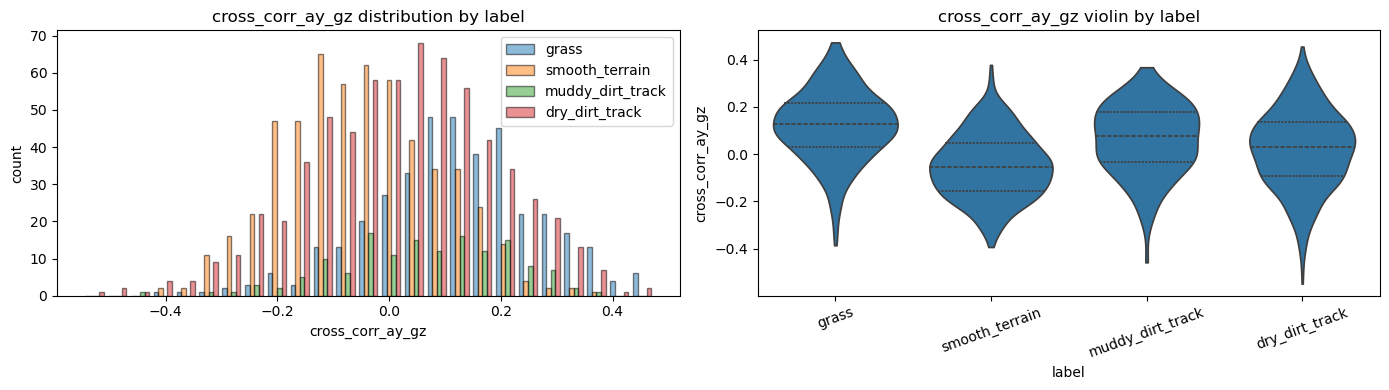

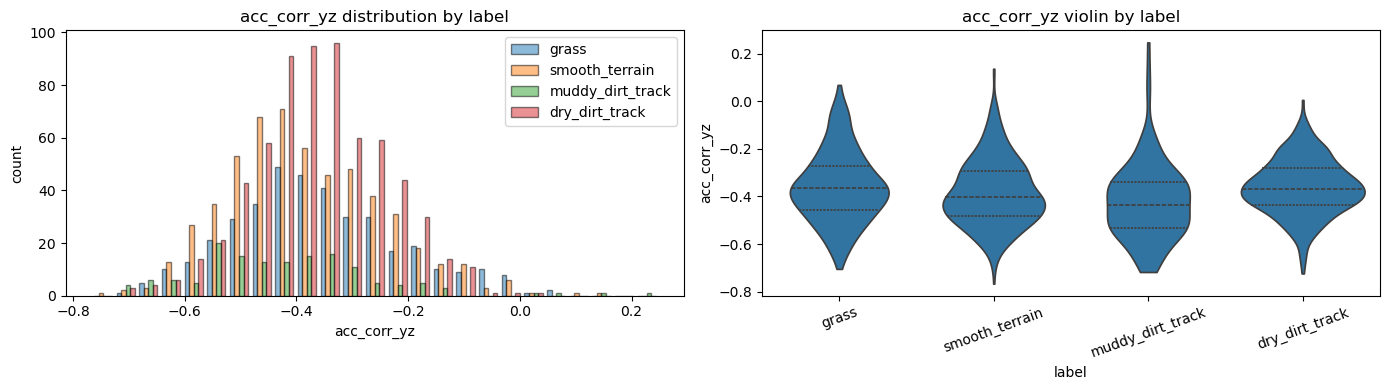

Saved 11 distribution figures to /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_A


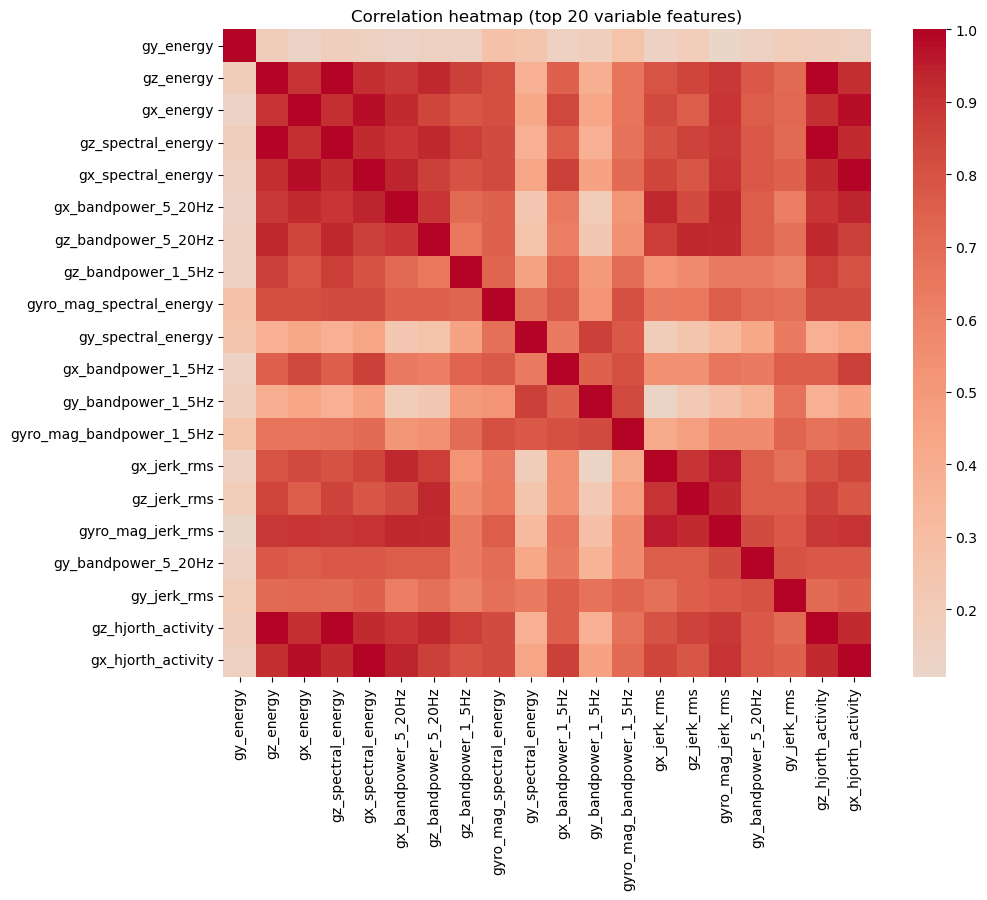

Top 15 absolute correlations among heatmap features:
          feature_1           feature_2     corr
 gz_spectral_energy  gz_hjorth_activity 1.000000
 gx_spectral_energy  gx_hjorth_activity 1.000000
          gz_energy  gz_hjorth_activity 0.993470
          gz_energy  gz_spectral_energy 0.993470
          gx_energy  gx_spectral_energy 0.980877
          gx_energy  gx_hjorth_activity 0.980877
        gx_jerk_rms   gyro_mag_jerk_rms 0.956457
gx_bandpower_5_20Hz  gx_hjorth_activity 0.943485
 gx_spectral_energy gx_bandpower_5_20Hz 0.943485
gz_bandpower_5_20Hz  gz_hjorth_activity 0.934797
 gz_spectral_energy gz_bandpower_5_20Hz 0.934797
gz_bandpower_5_20Hz         gz_jerk_rms 0.931278
gx_bandpower_5_20Hz   gyro_mag_jerk_rms 0.930354
gx_bandpower_5_20Hz         gx_jerk_rms 0.928546
          gz_energy gz_bandpower_5_20Hz 0.927686


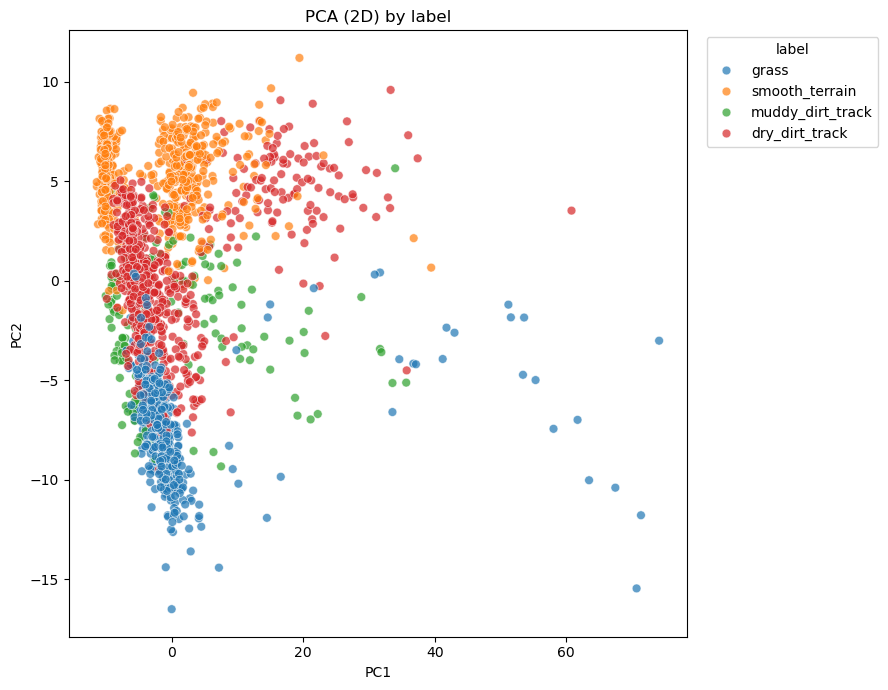

PCA explained variance ratio: [0.42625814 0.12781355]
PCA cumulative explained variance: 0.5540716915545028


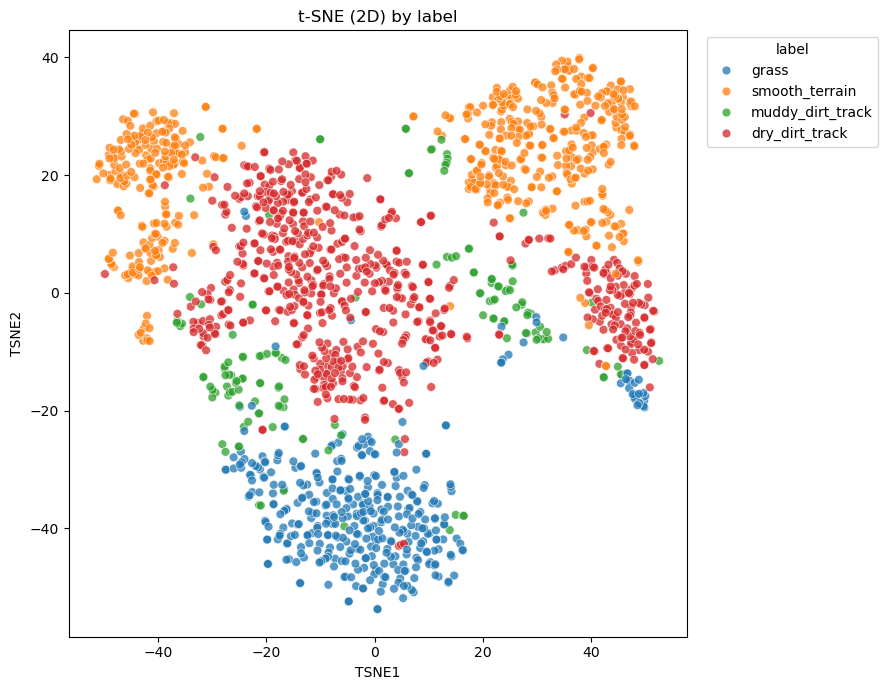

Saved PCA and t-SNE figures to: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_A
Dataset A EDA saved to: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_A


In [ ]:
reports_dir_A = PROJECT_ROOT / "reports" / "features" / "dataset_A"

# These features are physically interpretable and known to be discriminative
# for terrain type in wheeled robot navigation.
VIZ_FEATURES = [
    # Accelerometer magnitude — overall vibration
    "acc_mag_rms",
    "acc_mag_std",
    "acc_mag_bandpower_5_20Hz",
    # Per-axis accelerometer — directional vibration
    "ay_rms",              # vertical vibration (main terrain roughness signal)
    "az_rms",              # longitudinal vibration (traction events)
    "ay_jerk_rms",         # abrupt vertical changes (bumps, potholes)
    # Gyroscope magnitude — rotational instability
    "gyro_mag_rms",
    "gyro_mag_bandpower_5_20Hz",
    # Per-axis gyro — directional rotation
    "gx_rms",              # pitch rate (nose-up/down)
    "gz_rms",              # roll rate (side-to-side tilting)
    # Cross-sensor coupling — terrain-specific IMU interaction
    "cross_ay_gx",         # vertical bounce × pitch (mud sinkage)
    "cross_ay_gz",         # vertical bounce × roll (uneven wheel sinkage)
    # Odometry
    "odom_mean_speed",
]

eda_feat_cols_A = get_eda_feature_columns(dataset_A_tf, id_cols=ID_COLS)

eval_A = run_feature_evaluation(
    features_df     = dataset_A_tf,
    reports_dir     = reports_dir_A,
    viz_features    = VIZ_FEATURES,
    label_col       = "label",
    id_cols         = ID_COLS,
    feature_cols    = eda_feat_cols_A,
    top_n_heatmap   = TOP_N_HEATMAP,
    random_state    = RANDOM_STATE,
    tsne_sample_cap = TSNE_SAMPLE_CAP,
    show            = True,
)
print(f"Dataset A EDA saved → {reports_dir_A}")

## Cell 5 — Full EDA: Dataset B (speed-controlled)

If the t-SNE of Dataset B shows **cleaner class separation** than Dataset A,
it confirms that velocity variation was masking terrain signal.
In that case, consider training the production model on Dataset B (lower speed range)
or adding speed as an explicit normalisation step.

Feature table diagnostics
Shape: (1160, 238)
Feature count: 231
Total missing values in feature columns: 0

Label distribution:
                  count    pct
label                         
dry_dirt_track      523  45.09
grass               354  30.52
muddy_dirt_track     75   6.47
smooth_terrain      208  17.93

Quick summary (key separator candidates):
                  acc_mag_rms  acc_mag_std  acc_mag_energy  gyro_mag_rms  gyro_mag_std  gyro_mag_energy
label                                                                                                  
dry_dirt_track         0.1125       0.0480          1.2453       11.6673        1.8413          10.2007
grass                  0.1184       0.0498          1.3298       11.8131        2.2116          10.2257
muddy_dirt_track       0.0872       0.0387          0.9081       10.6727        1.8397          10.0153
smooth_terrain         0.0660       0.0287          0.6273       10.4686        0.9659           9.9807


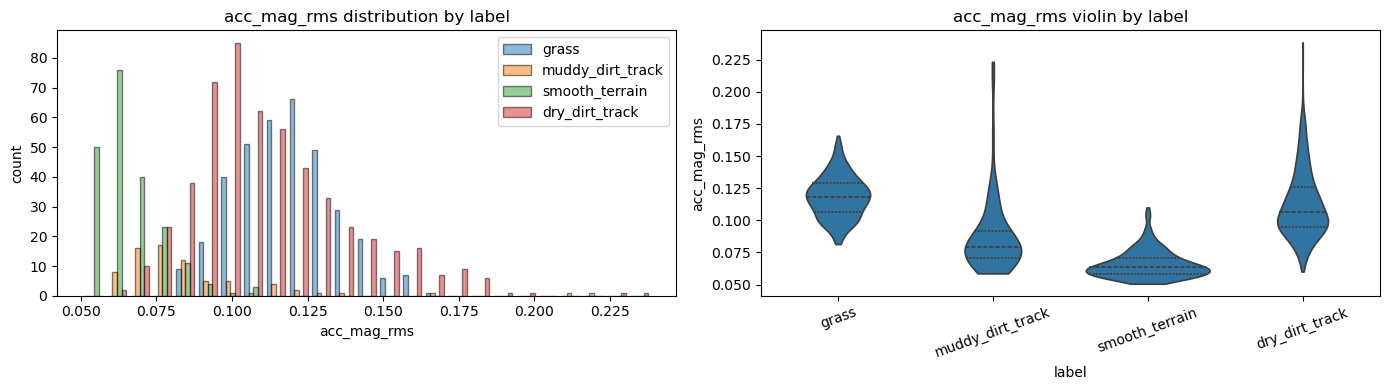

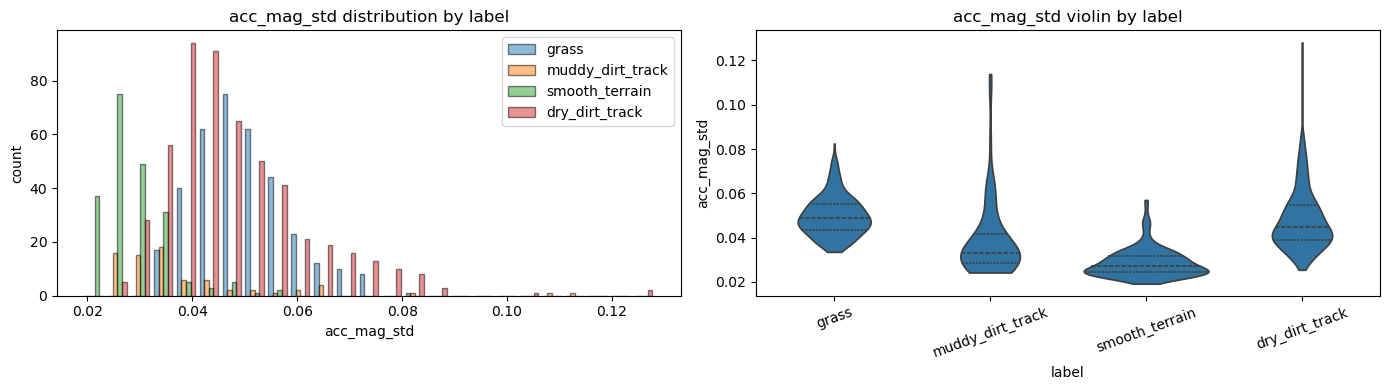

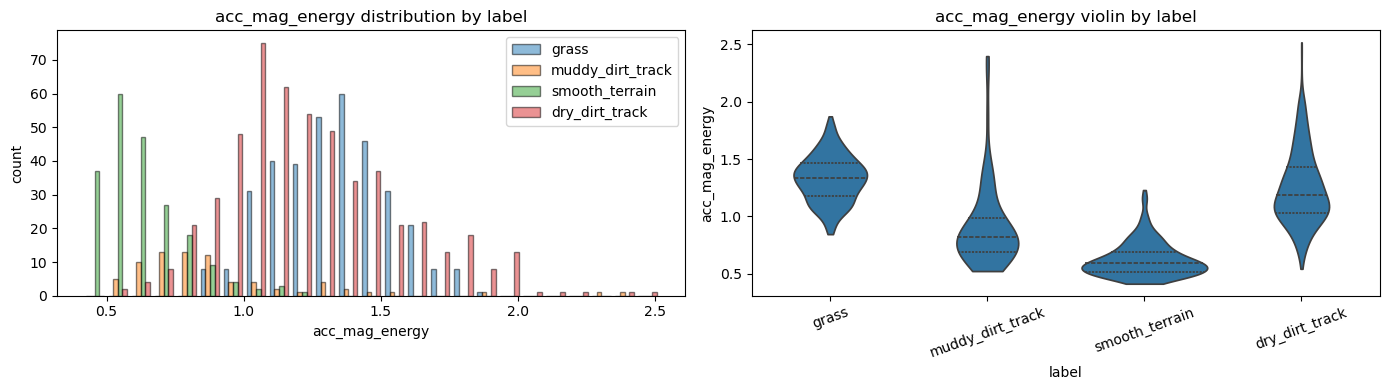

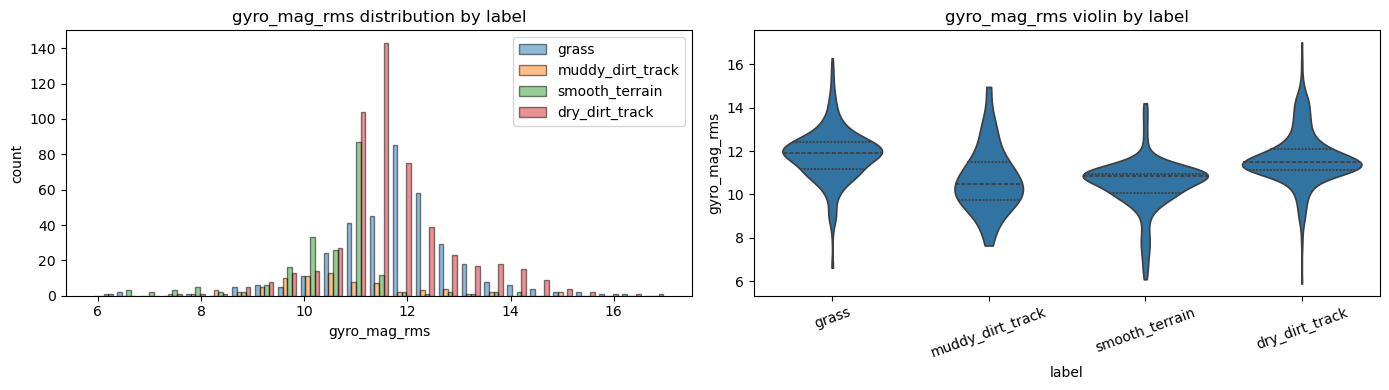

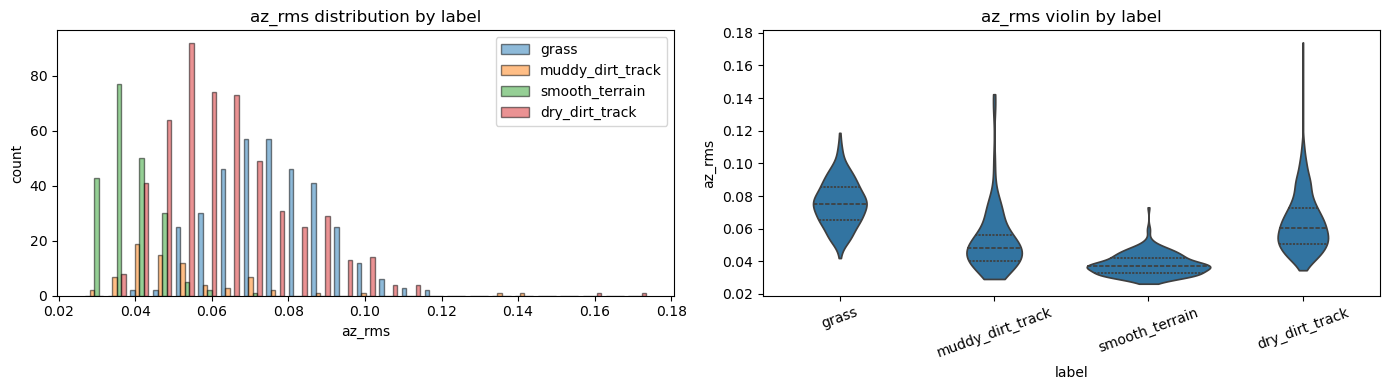

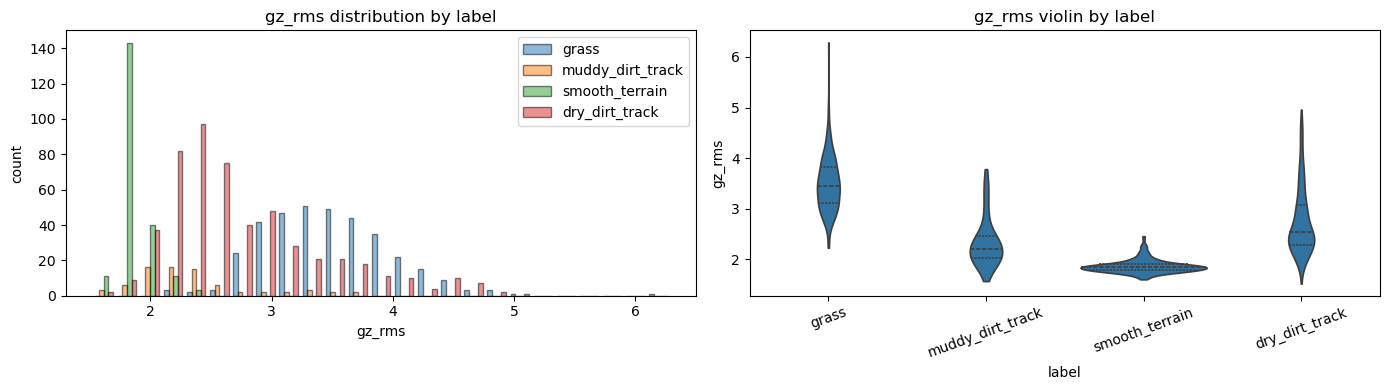

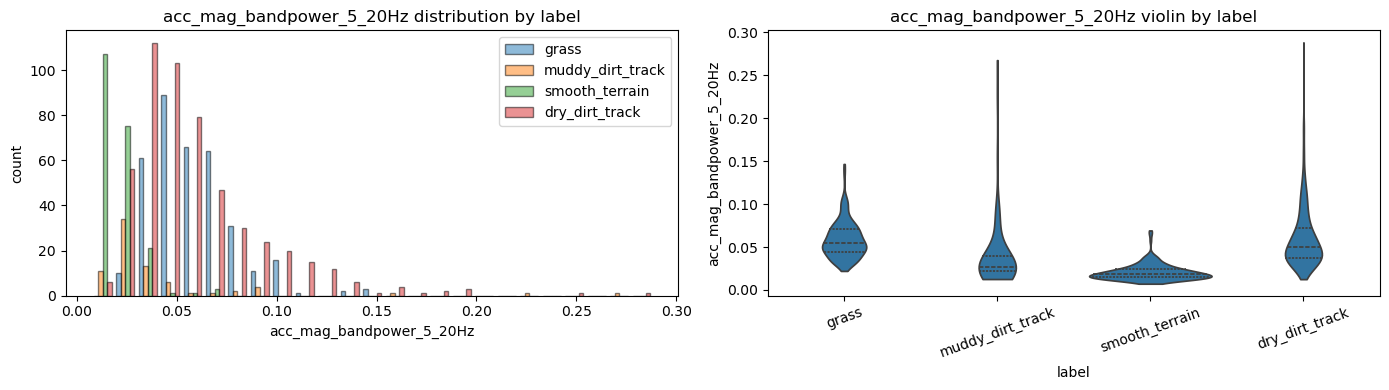

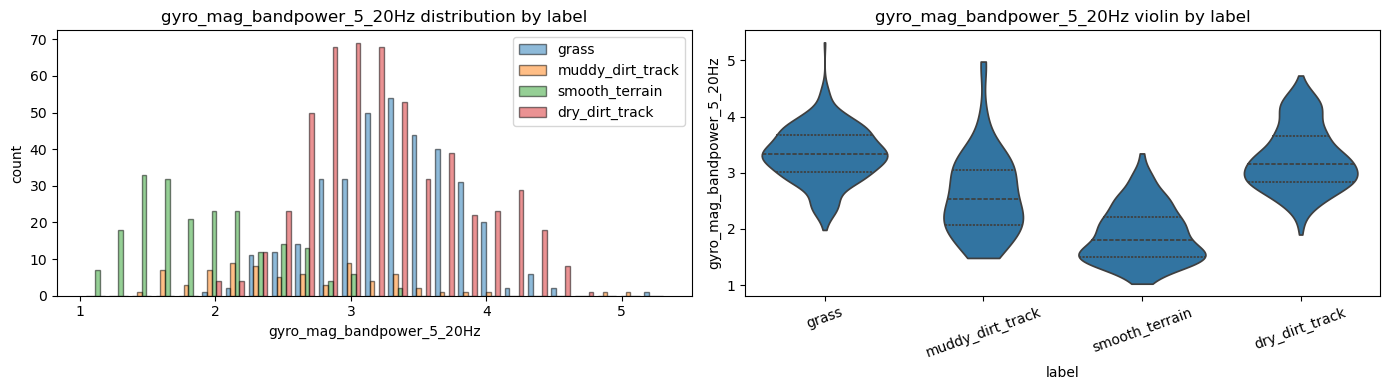

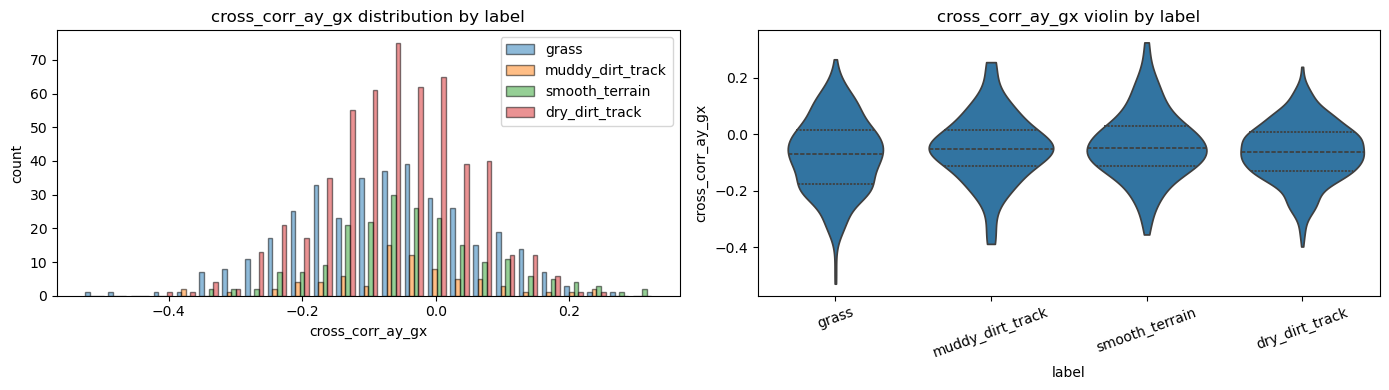

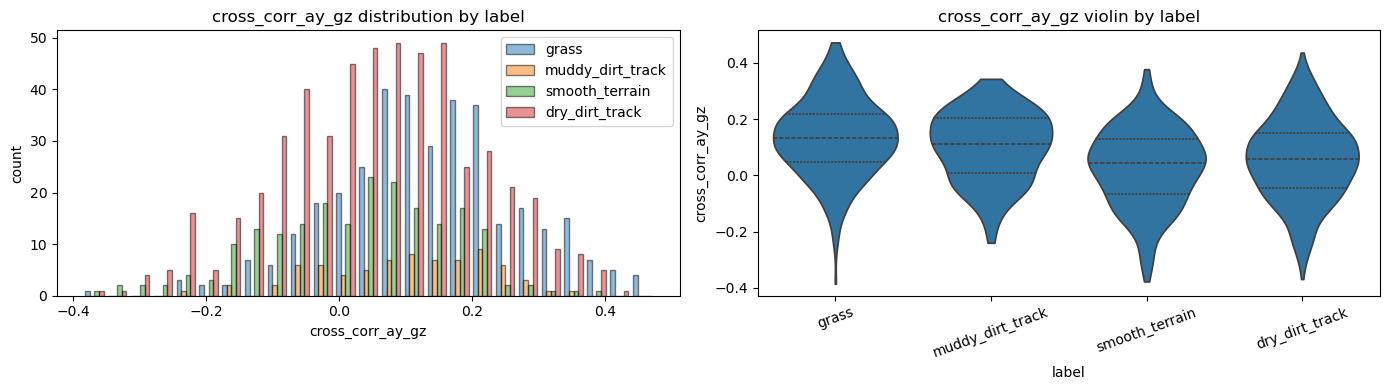

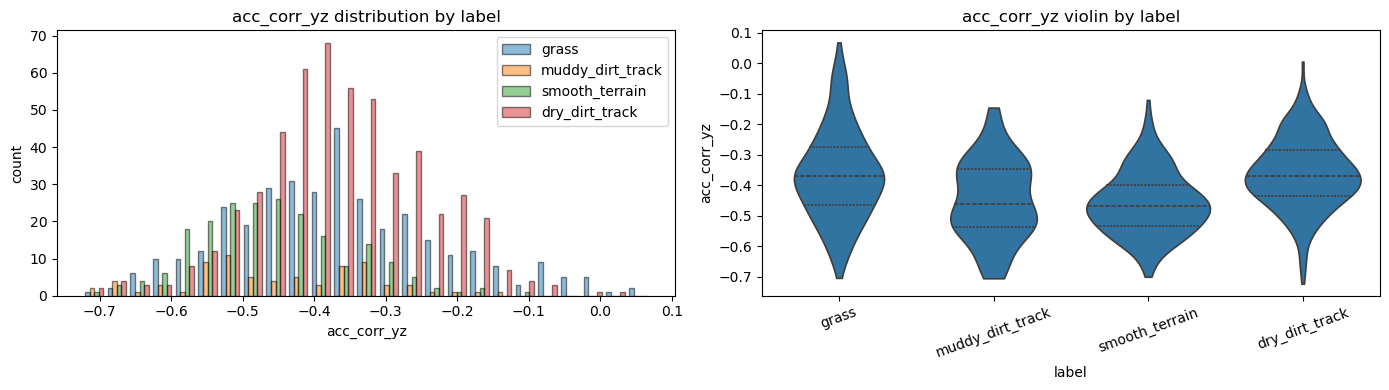

Saved 11 distribution figures to /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B


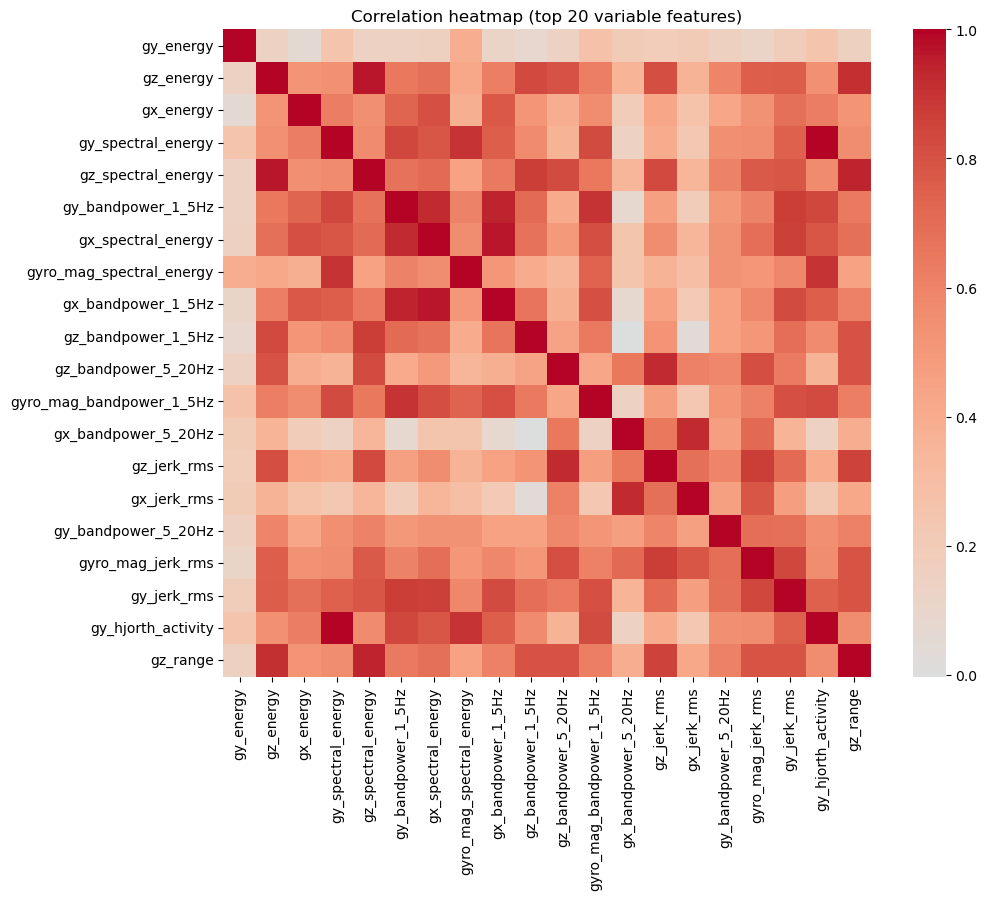

Top 15 absolute correlations among heatmap features:
               feature_1                feature_2     corr
      gy_spectral_energy       gy_hjorth_activity 1.000000
      gx_spectral_energy       gx_bandpower_1_5Hz 0.967126
               gz_energy       gz_spectral_energy 0.964001
      gy_bandpower_1_5Hz       gx_bandpower_1_5Hz 0.944557
      gz_spectral_energy                 gz_range 0.939622
     gx_bandpower_5_20Hz              gx_jerk_rms 0.927502
     gz_bandpower_5_20Hz              gz_jerk_rms 0.927172
      gy_bandpower_1_5Hz       gx_spectral_energy 0.925513
               gz_energy                 gz_range 0.910637
      gy_bandpower_1_5Hz gyro_mag_bandpower_1_5Hz 0.904107
gyro_mag_spectral_energy       gy_hjorth_activity 0.898596
      gy_spectral_energy gyro_mag_spectral_energy 0.898596
      gz_spectral_energy       gz_bandpower_1_5Hz 0.873564
             gz_jerk_rms        gyro_mag_jerk_rms 0.868917
      gy_bandpower_1_5Hz              gy_jerk_rms 0.867553


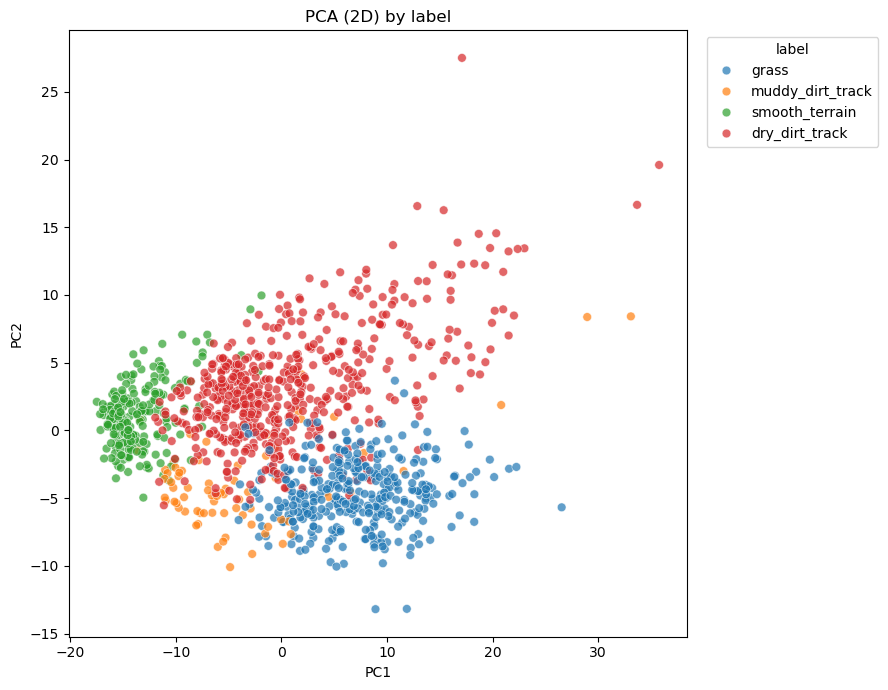

PCA explained variance ratio: [0.38723797 0.10462979]
PCA cumulative explained variance: 0.4918677652052073


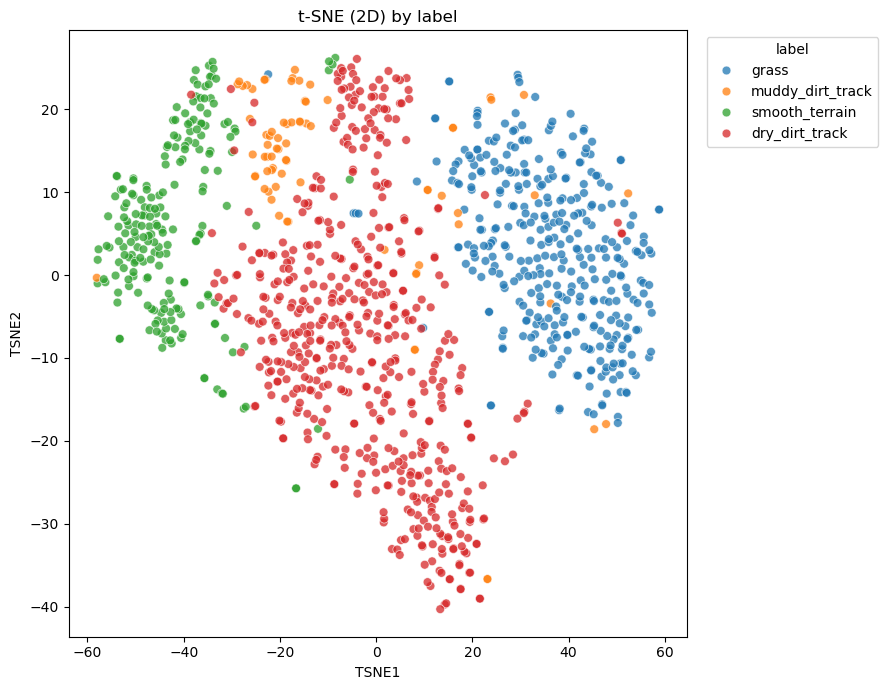

Saved PCA and t-SNE figures to: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B
Dataset B EDA saved to: /Users/pratyush/Desktop/DTU/Bachelor_thesis/BSC_Thesis_intrinsic_sensor_analysis/reports/features/dataset_B


In [ ]:
reports_dir_B = PROJECT_ROOT / "reports" / "features" / "dataset_B"

eda_feat_cols_B = get_eda_feature_columns(dataset_B_tf, id_cols=ID_COLS)

eval_B = run_feature_evaluation(
    features_df     = dataset_B_tf,
    reports_dir     = reports_dir_B,
    viz_features    = VIZ_FEATURES,
    label_col       = "label",
    id_cols         = ID_COLS,
    feature_cols    = eda_feat_cols_B,
    top_n_heatmap   = TOP_N_HEATMAP,
    random_state    = RANDOM_STATE,
    tsne_sample_cap = TSNE_SAMPLE_CAP,
    show            = True,
)
print(f"Dataset B EDA saved → {reports_dir_B}")

## Cell 6 — Mutual information scoring

MI measures how much knowing a feature reduces uncertainty about the terrain label.
Unlike Pearson correlation, MI captures non-linear relationships.

> **Note:** For final model training, recompute MI on the **train split only** to avoid
> label leakage into feature selection.  Running it here on the full dataset is fine
> for exploratory use — the leakage effect is minor but present.

We run MI on **Dataset B** (speed-controlled) so scores are not inflated by
velocity-correlated features.

Top 30 features by mutual information:
             feature  mi_score
gz_spectral_centroid  0.834576
  gz_hjorth_mobility  0.825451
  gz_bandpower_1_5Hz  0.750472
  gx_hjorth_mobility  0.683273
ay_hjorth_complexity  0.675895
ax_hjorth_complexity  0.671605
              gz_iqr  0.636376
              gz_std  0.622687
  gz_spectral_energy  0.622436
  gz_hjorth_activity  0.622436
gx_spectral_centroid  0.610522
gx_hjorth_complexity  0.609647
              gx_std  0.603710
  gx_spectral_energy  0.603202
  gx_hjorth_activity  0.603202
  gx_bandpower_1_5Hz  0.595780
              gz_ptp  0.588138
            gz_range  0.588138
              gz_max  0.587888
              gx_iqr  0.578998
        odom_vel_std  0.575229
az_hjorth_complexity  0.572471
         gy_jerk_rms  0.550790
              gz_min  0.548126
  gy_bandpower_1_5Hz  0.546797
ay_spectral_centroid  0.539905
           gz_energy  0.519713
              gz_rms  0.519417
  ax_bandpower_1_5Hz  0.506139
 gx_spectral_entropy  0.500007


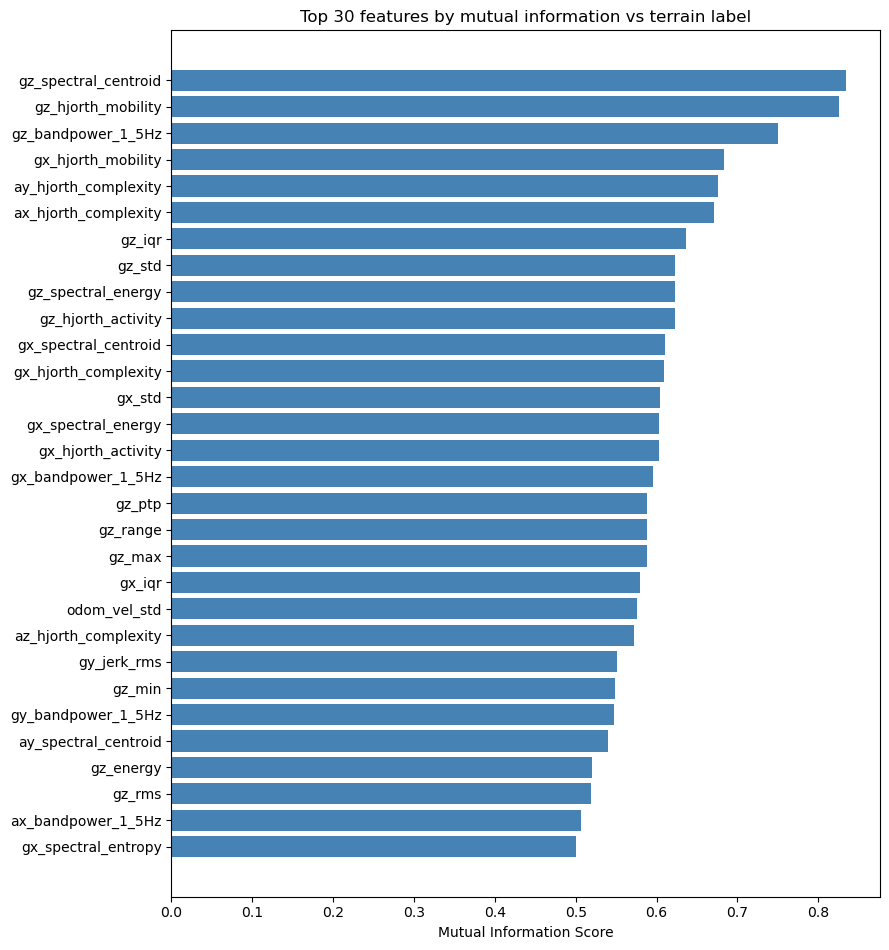


Top 25 features for modelling:
['gz_spectral_centroid', 'gz_hjorth_mobility', 'gz_bandpower_1_5Hz', 'gx_hjorth_mobility', 'ay_hjorth_complexity', 'ax_hjorth_complexity', 'gz_iqr', 'gz_std', 'gz_spectral_energy', 'gz_hjorth_activity', 'gx_spectral_centroid', 'gx_hjorth_complexity', 'gx_std', 'gx_spectral_energy', 'gx_hjorth_activity', 'gx_bandpower_1_5Hz', 'gz_ptp', 'gz_range', 'gz_max', 'gx_iqr', 'odom_vel_std', 'az_hjorth_complexity', 'gy_jerk_rms', 'gz_min', 'gy_bandpower_1_5Hz']


In [ ]:
mi_df = compute_mutual_information(
    features_df  = dataset_B_tf,
    feature_cols = feature_cols,   # full feature set
    label_col    = "label",
    n_neighbors  = 5,
    random_state = RANDOM_STATE,
    top_n        = 30,
    plot         = True,
    reports_dir  = reports_dir_B,
    show         = True,
)

# Save top-25 feature names for easy reference in 07_modelling
top_features = mi_df.head(25)["feature"].tolist()
print(f"\nTop 25 features by MI (Dataset B):")
for i, f in enumerate(top_features, 1):
    print(f"  {i:2d}. {f}")

## Cell 7 — Mutual information on Dataset A

Compare with Dataset B — features that rank highly in **both** are robustly
terrain-discriminative regardless of speed regime.

In [ ]:
mi_df_A = compute_mutual_information(
    features_df  = dataset_A_tf,
    feature_cols = feature_cols,
    label_col    = "label",
    n_neighbors  = 5,
    random_state = RANDOM_STATE,
    top_n        = 30,
    plot         = True,
    reports_dir  = reports_dir_A,
    show         = True,
)

# Compare top-15 between the two datasets
top_A = set(mi_df_A.head(15)["feature"])
top_B = set(mi_df.head(15)["feature"])
print(f"\nFeatures in top-15 for BOTH datasets ({len(top_A & top_B)} features):")
for f in sorted(top_A & top_B):
    print(f"  {f}")
print(f"\nOnly in Dataset A top-15: {sorted(top_A - top_B)}")
print(f"Only in Dataset B top-15: {sorted(top_B - top_A)}")

Dropped 73 highly correlated features (threshold=0.95):
  acc_mag_hjorth_activity
  acc_mag_hjorth_mobility
  acc_mag_mean
  acc_mag_mean_abs
  acc_mag_median
  acc_mag_ptp
  acc_mag_range
  acc_mag_rms
  acc_mag_sma
  acc_mag_std
  ax_hjorth_activity
  ax_hjorth_mobility
  ax_mean_abs
  ax_min
  ax_range
  ax_rms
  ax_sma
  ax_spectral_energy
  ax_std
  ay_bandpower_5_20Hz
  ay_detrended_rms
  ay_detrended_std
  ay_hjorth_activity
  ay_mean_abs
  ay_range
  ay_rms
  ay_sma
  ay_spectral_energy
  ay_std
  az_bandpower_1_5Hz
  az_hjorth_activity
  az_hjorth_mobility
  az_mean_abs
  az_range
  az_rms
  az_sma
  az_spectral_energy
  az_std
  gx_bandpower_1_5Hz
  gx_hjorth_activity
  gx_hjorth_mobility
  gx_range
  gx_rms
  gx_sma
  gx_std
  gy_bandpower_40_80Hz
  gy_hjorth_activity
  gy_mean
  gy_mean_abs
  gy_min
  gy_range
  gy_rms
  gy_sma
  gy_std
  gyro_mag_energy
  gyro_mag_hjorth_activity
  gyro_mag_mean
  gyro_mag_mean_abs
  gyro_mag_median
  gyro_mag_range
  gyro_mag_rms
  gyro_m

## Cell 8 — Correlation pruning (Dataset B)

Many features are near-identical (e.g. `rms` and `std` on a zero-mean signal are
mathematically equivalent; `energy` and `rms` are monotonically related).
Dropping them reduces model training time and the risk of instability in  
linear models without reducing predictive information.

We prune Dataset B — the dataset most likely to be used for model training.

In [ ]:
CORR_THRESHOLD = 0.95   # drop one of any pair with |Pearson r| > this

dataset_B_pruned, dropped_cols = drop_high_correlation_features(
    dataset_B_tf,
    feature_cols = feature_cols,
    threshold    = CORR_THRESHOLD,
    id_cols      = ID_COLS,
)

remaining_cols = get_feature_columns(dataset_B_pruned, id_cols=ID_COLS)
print(f"\nBefore pruning : {len(feature_cols)} features")
print(f"After pruning  : {len(remaining_cols)} features")
print(f"Dropped        : {len(dropped_cols)} features")

## Cell 9 — (Optional) Inspect specific terrain-pair separability

The hardest pairs to separate in this dataset are typically:
- `grass` vs `dry_dirt_track` (both firm, low vibration)
- `muddy_dirt_track` vs `dry_dirt_track` (similar texture, different wheel-ground coupling)

This cell plots the top-5 MI features as violin plots **only for these two pairs** to
check whether the features genuinely separate them.

In [ ]:
import seaborn as sns

HARD_PAIRS = [
    ("grass",          "dry_dirt_track"),
    ("muddy_dirt_track", "dry_dirt_track"),
]

# Top-5 features from Dataset B MI
top5 = mi_df.head(5)["feature"].tolist()

for cls_a, cls_b in HARD_PAIRS:
    subset = dataset_B_tf[
        dataset_B_tf["label"].isin([cls_a, cls_b])
    ]
    if subset.empty:
        print(f"No data for pair ({cls_a}, {cls_b}) — skipping.")
        continue

    fig, axes = plt.subplots(1, len(top5), figsize=(4 * len(top5), 4), sharey=False)
    fig.suptitle(f"Separability: {cls_a}  vs  {cls_b}", fontsize=12)

    for ax, feat in zip(axes, top5):
        if feat not in subset.columns:
            ax.set_visible(False)
            continue
        sns.violinplot(
            data=subset, x="label", y=feat, ax=ax,
            inner="quartile", cut=0, palette="Set2",
        )
        ax.set_title(feat, fontsize=9)
        ax.set_xlabel("")
        ax.tick_params(axis="x", rotation=25)

    fig.tight_layout()
    plt.show()

## Cell 10 — Save outputs

| File | Contents |
|------|----------|
| `dataset_A_features.csv` | All windows, log-transformed, **not** pruned |
| `dataset_B_features.csv` | Speed-controlled, log-transformed, correlation-pruned |

Both files are ready to be loaded directly in `07_modelling.ipynb`.

In [ ]:
out_dir = PROJECT_ROOT / "data" / "processed"
out_dir.mkdir(parents=True, exist_ok=True)

path_A = out_dir / "dataset_A_features.csv"
path_B = out_dir / "dataset_B_features.csv"

dataset_A_tf.to_csv(path_A, index=False)
dataset_B_pruned.to_csv(path_B, index=False)

print("Saved:")
print(f"  Dataset A : {path_A}  {dataset_A_tf.shape}")
print(f"  Dataset B : {path_B}  {dataset_B_pruned.shape}")
print(f"\nTop-25 MI features (Dataset B) for 07_modelling:")
print(top_features)
print("\nReady for 07_modelling.ipynb ✓")